<a href="https://colab.research.google.com/github/huangfu0411/harry-s-respository/blob/main/A2_RealizedVol_completed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2 — Diversification, and Your First Sort


Graded on completion. Work in your group of three; each of you submits your own copy.

---

**Group members**

- Name / NYU email:
- Name / NYU email:
- Name / NYU email:

---

Three parts. **Part 1** is the same for everybody and answers a question Lecture 2
deliberately left open. **Part 2**, also the same for everybody, walks you through
NYSE breakpoints — the convention research papers use to build sorted
portfolios — and what that one choice does to two famous results. **Part 3** is
where your group's own strategy starts — everything you do for the rest of the
term builds on it.

Use AI freely. You will be asked to explain what you did.

## 🛠️ Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [10, 4]
import warnings; warnings.filterwarnings('ignore')

BASE  = "https://raw.githubusercontent.com/amoreira2/UG54/refs/heads/main/assets/data"
panel = pd.read_parquet(f"{BASE}/panel_backbone_1980_2000.parquet")
menu  = pd.read_csv(f"{BASE}/signal_menu.csv")

print(f"{len(panel):,} stock-months, {panel.permno.nunique():,} stocks, "
      f"{panel.date.nunique()} months")
print(f"{len(menu)} signals on the menu")

1,517,174 stock-months, 17,800 stocks, 252 months
30 signals on the menu


---

# Part 1 — How much does diversification actually buy you?

In Lecture 2 we found that a typical stock runs about **52% volatility a year**
while the whole market runs **15.5%**, and left two questions hanging. This is
the first one:

> There are roughly 6,000 stocks. If they moved independently, averaging them
> would drive volatility to almost nothing. It stops at 15.5%. **Why?**

You are going to answer it by measuring, not by being told.

### Q1 — A clean set of stocks to work with

Comparing portfolios of different sizes only makes sense if every portfolio
covers the same months. Build a **wide** table — dates down the rows, one column
per stock, returns in the cells — keeping only stocks that are present for the
**entire** sample.

> **📝 Spec.** From `panel`, produce a DataFrame `W` indexed by `date` with one
> column per `permno`, containing `ret`. Drop any stock that has a missing month.
> Report how many stocks survive.

> **🤖 A prompt that gets you close:** *"Pivot a long DataFrame with columns
> permno, date, ret into a wide DataFrame indexed by date with one column per
> permno, then drop every column that contains any NaN."*

In [ ]:
W = panel.pivot_table(index='date', columns='permno', values='ret').dropna(axis=1)
print(f"{W.shape[1]} stocks with a complete {W.shape[0]}-month history")

979 stocks with a complete 252-month history


### Q2 — The volatility of an equal-weighted portfolio of N stocks

Write a function that takes a number of stocks `N`, picks `N` of them **at
random** from `W`, forms the equal-weighted portfolio, and returns its
**annualized** volatility.

Two things to be careful about. An equal-weighted portfolio of a set of columns
is just their average, row by row. And annualizing a monthly volatility means
multiplying by √12, not by 12.

In [ ]:
rng = np.random.default_rng(0)      # so your answers are reproducible

def port_vol(N):
    """Annualized volatility of an equal-weighted portfolio of N random stocks."""
    cols = rng.choice(W.columns, size=N, replace=False)
    port_ret = W[cols].mean(axis=1)
    return port_ret.std() * np.sqrt(12)

print(f"one draw of 10 stocks: {port_vol(10):.1%}")

one draw of 10 stocks: 18.9%


### Q3 — Average over many draws

One draw is noise — you might happen to pick ten utilities. Write
`avg_port_vol(N, n_draws=100)` that repeats Q2 `n_draws` times and returns the
average.

In [ ]:
def avg_port_vol(N, n_draws=100):
    vols = [port_vol(N) for _ in range(n_draws)]
    return np.mean(vols)

print(f"N=10, averaged over 100 draws: {avg_port_vol(10):.1%}")

N=10, averaged over 100 draws: 18.8%


### Q4 — The curve

Compute `avg_port_vol` for **N = 1, 2, 5, 10, 20, 50, 100, 200** and plot it
against N. Put N on a log scale — the interesting action is at small N.

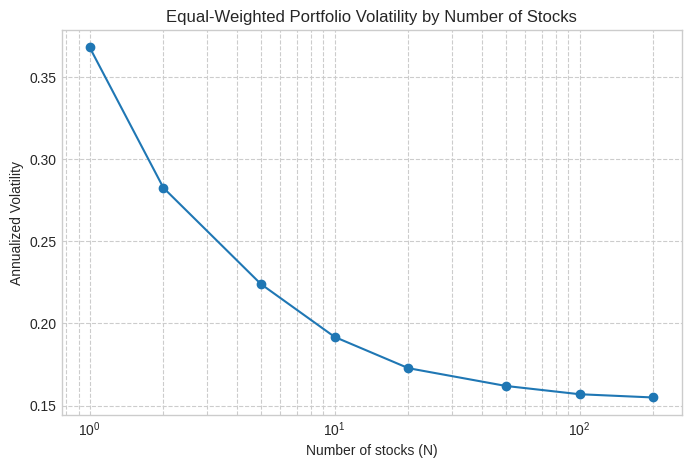

In [ ]:
NS = [1, 2, 5, 10, 20, 50, 100, 200]

vols = [avg_port_vol(N) for N in NS]

plt.figure(figsize=(8, 5))
plt.plot(NS, vols, marker='o', linestyle='-')
plt.xscale('log')
plt.xlabel('Number of stocks (N)')
plt.ylabel('Annualized Volatility')
plt.title('Equal-Weighted Portfolio Volatility by Number of Stocks')
plt.grid(True, which="both", ls="--")
plt.show()

### Q5 — Two reference lines

The plot on its own does not tell you what it *should* have looked like. Add
two lines.

**Line A — what you would get if stocks were independent.** If N stocks each had
volatility σ and were uncorrelated, the equal-weighted portfolio's volatility
would be σ/√N. Use the average single-stock volatility in `W` for σ, and draw
that curve across the same range of N.

**Line B — the market.** Compute the value-weighted market return from `panel`
(you built this in Lecture 2: weight by `me` lagged one month, earn this
month's `ret`) and draw its annualized volatility as a horizontal line.

> **⚠️ Careful.** Line A is *not* a fitted line or a prediction. It is what the
> arithmetic gives you under an assumption you have every reason to doubt. The
> point of drawing it is to see how badly the assumption fails.

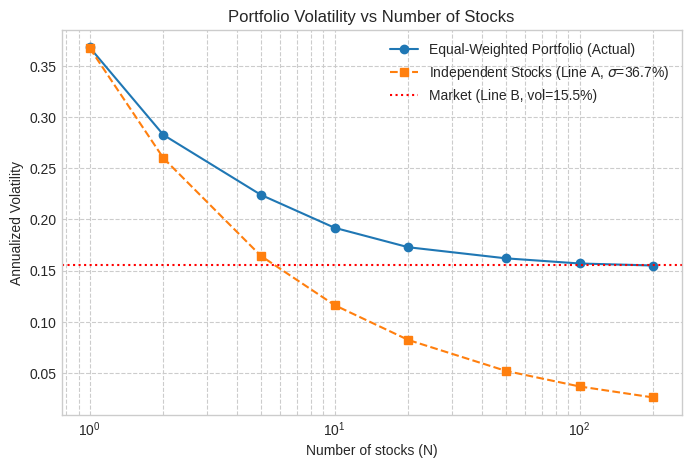

In [ ]:
# Line A: what you would get if stocks were independent
# Average single-stock annualized volatility
sigma = (W.std() * np.sqrt(12)).mean()
indep_vols = [sigma / np.sqrt(N) for N in NS]

# Line B: the market
# Compute value-weighted market return (weight by lagged 'me')
p_temp = panel.copy()
p_temp['me_l1'] = p_temp.groupby('permno')['me'].shift(1)
p_temp = p_temp.dropna(subset=['me_l1', 'ret'])
mkt_ret = p_temp.groupby('date').apply(lambda x: np.average(x['ret'], weights=x['me_l1']))
mkt_vol = mkt_ret.std() * np.sqrt(12)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(NS, vols, marker='o', linestyle='-', label='Equal-Weighted Portfolio (Actual)')
plt.plot(NS, indep_vols, marker='s', linestyle='--', label=f'Independent Stocks (Line A, $\sigma$={sigma:.1%})')
plt.axhline(mkt_vol, color='red', linestyle=':', label=f'Market (Line B, vol={mkt_vol:.1%})')

plt.xscale('log')
plt.xlabel('Number of stocks (N)')
plt.ylabel('Annualized Volatility')
plt.title('Portfolio Volatility vs Number of Stocks')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

### Q6 — Read your own plot

> **📝 Answer in the cell below — a short paragraph each, no code.**
>
> **(a)** Roughly where does your curve stop falling? Give an N.
>
> **(b)** The independent line keeps going down and your curve does not. Describe
> the gap between them at N = 200 and say, in your own words, what is in that
> gap. What is it about real stocks that the independent calculation ignores?
>
> **(c)** Look at where your curve levels off relative to the market line. Is
> that a coincidence? What would have to be true for a large equal-weighted
> portfolio to end up at the market's volatility?
>
> **(d)** You are about to build a long-short portfolio out of roughly 600
> stocks per leg. Given this plot, what does that buy you — and what does it
> *not* protect you from?

**(a)** The curve is mostly flat by about 50-100 stocks. Annualized volatility is about 16.2% at N = 50, 15.7% at N = 100, and 15.5% at N = 200, so the extra reduction becomes small.

**(b)** At N = 200, actual volatility is about 15.5%, while the independent-stock benchmark is about 2.6%, a gap of about 12.9 percentage points. Real stocks share market and economic shocks, so their returns are positively correlated. Averaging many stocks reduces company-specific risk but does not eliminate this common component.

**(c)** The curve levels off close to the value-weighted market's 15.5% volatility. Both portfolios contain common market risk, but exact equality is not guaranteed: their weights, stock selection, and factor exposures differ. For a large equal-weighted portfolio to have the market's volatility, its combined common-risk exposures would need to produce similar variance and its remaining company-specific risk would need to be small. This experiment also uses only stocks with complete histories, whereas the market portfolio uses the broader panel.

**(d)** About 600 stocks per leg should diversify much of the individual-company risk. It does not guarantee a safe long-short portfolio: different market, industry, or other factor exposures between the two legs can leave substantial common risk. Holding many names does not by itself make the long and short risks cancel.


---

# Part 2 — NYSE breakpoints, and why the details decide the answer

In the sorts lecture you cut stocks into ten equal-count buckets with `pd.qcut`,
over every stock in the market. Research papers almost never do that. They use
**NYSE breakpoints**. This part builds them one step at a time, then uses them on
one of the oldest results in finance — that small stocks outperform (Banz, 1981)
— and on value.

Most of the code is written for you. Run each cell, read what it prints, and make
sure you can say what every line does. The questions are where you do the work.

**Why equal-count buckets are a problem.** There are about 6,000 stocks, and the
ten largest are a fifth of the market's value. Size is so skewed that an
equal-count bottom decile is roughly 600 of the smallest companies in the
country: firms worth a few million dollars, many of which barely trade.

**The fix.** Compute the cutoffs from **NYSE-listed stocks only**, `exchcd == 1`,
then apply them to **every** stock. NYSE firms are larger and more established,
so "small" is defined relative to them rather than relative to the microcap
tail. Fama and French do this, and so does almost every published paper.

The timing is the lecture's: everything you condition on is last month's value,
and the return you earn is this month's `ret`.

### Step 1 — Last month's size

In [ ]:
panel['me_l1'] = panel.groupby('permno')['me'].shift(1)
d0 = panel.dropna(subset=['ret', 'me_l1'])

print(f"{len(d0):,} stock-months with a return and last month's size")
print(f"stocks per month: {d0.groupby('date').size().mean():,.0f} in all, "
      f"{d0[d0.exchcd == 1].groupby('date').size().mean():,.0f} of them on the NYSE")

1,499,374 stock-months with a return and last month's size
stocks per month: 5,974 in all, 1,496 of them on the NYSE


### Step 2 — The cutoffs, from NYSE stocks only

For each month, the 10th and 90th percentile of `me_l1` among NYSE stocks. Read
the chain one piece at a time:

| Piece | What it does |
|---|---|
| `d0[d0.exchcd == 1]` | keeps NYSE stocks only |
| `.groupby('date')['me_l1']` | one pile of market caps per month |
| `.quantile([.1, .9])` | the 10th and 90th percentile of each pile: two numbers per month |
| `.unstack()` | turns those two numbers into two columns |
| `.rename(columns={0.1: 'lo', 0.9: 'hi'})` | gives the columns names |

In [ ]:
q = (d0[d0.exchcd == 1].groupby('date')['me_l1']
       .quantile([.1, .9]).unstack().rename(columns={0.1: 'lo', 0.9: 'hi'}))

print(f"{len(q)} months of cutoffs, in $ millions:\n")
print((q / 1000).round(1).head(3).to_string())      # me is in $ thousands

251 months of cutoffs, in $ millions:

              lo      hi
date                    
1980-02-29  33.1  1315.8
1980-03-31  32.0  1305.7
1980-04-30  26.5  1139.1


In February 1980 a stock counts as small below about \$33 million and as big
above about \$1.3 billion. Those cutoffs come from NYSE stocks alone. Nothing has
been applied to anybody yet.

### Step 3 — Apply the cutoffs to every stock

`merge` on `date` copies each month's `lo` and `hi` onto every stock in that
month — NYSE, AMEX and NASDAQ alike. Then `np.where` labels each stock-month.

`np.where(condition, a, b)` goes row by row: where the condition is true it
takes `a`, otherwise `b`. A second `np.where` in the `b` slot gives three
outcomes: `'S'` at or below `lo`, `'B'` at or above `hi`, and `None` — Python's
"nothing" — for everything in between.

In [ ]:
a = d0.merge(q, on='date')
a['g'] = np.where(a.me_l1 <= a.lo, 'S', np.where(a.me_l1 >= a.hi, 'B', None))

print(a['g'].value_counts(dropna=False).to_string(), "\n")    # stock-months with each label
a[['permno', 'date', 'exchcd', 'me_l1', 'lo', 'hi', 'g']].head()

g
S       781052
None    677943
B        40379 



,permno,date,exchcd,me_l1,lo,hi,g
0,10000,1986-03-31,3,11960.00000,58216.7500,3322723.875,S
1,10000,1986-04-30,3,16330.00000,62273.7875,3481356.450,S
2,10000,1986-05-31,3,15172.00000,60440.6000,3360823.975,S
3,10000,1986-06-30,3,11793.87793,62118.1500,3487836.425,S
4,10000,1986-07-31,3,11734.59375,60965.2500,3620287.000,S


### Q7 — How many stocks are "small"?

"Compute from NYSE, apply to every stock" is two clauses, and it is easy to merge
them into one. Count the stocks in the small bucket each month, averaged over
the months, under three readings:

1. **Cutoffs from NYSE, applied to every stock** — what Step 3 built.
2. **Cutoffs from NYSE, applied to NYSE stocks only** — the same labels, keeping
   only `exchcd == 1`.
3. **No breakpoints** — `pd.qcut` into ten equal-count buckets over every stock
   each month, as in the lecture, counting the bottom bucket.

> **🤖 A prompt that gets you close for reading 1:** *"From DataFrame `a`, keep
> the rows where `g == 'S'`, count the rows for each `date`, and take the mean of
> those counts."*

> **📌 Name your answers:**
> ```python
> n_small_nyse  = ____   # reading 1
> n_small_wrong = ____   # reading 2
> n_small_all   = ____   # reading 3
> ```

In [ ]:
n_small_nyse = a.loc[a.g == 'S'].groupby('date').size().mean()
n_small_wrong = a.loc[(a.g == 'S') & (a.exchcd == 1)].groupby('date').size().mean()
all_deciles = d0.groupby('date')['me_l1'].transform(
    lambda x: pd.qcut(x, 10, labels=False, duplicates='drop'))
n_small_all = d0.loc[all_deciles == 0].groupby('date').size().mean()

print(f"{'cutoffs from NYSE, applied to every stock':44s}{n_small_nyse:>7,.0f}")
print(f"{'cutoffs from NYSE, applied to NYSE only':44s}{n_small_wrong:>7,.0f}")
print(f"{'no breakpoints: qcut over every stock':44s}{n_small_all:>7,.0f}")


cutoffs from NYSE, applied to every stock     3,112
cutoffs from NYSE, applied to NYSE only         150
no breakpoints: qcut over every stock           598


> **✅ Check.** You should get about **3,100**, **150** and **600**. If you
> don't, go back to the three readings before moving on — everything after this
> depends on it.

**Q7, in words.** Two or three sentences. Why does "small relative to NYSE" take
in half the market, when "the smallest tenth of everything" is 600 stocks? And
what are the 150 stocks of reading 2 — what kind of company ends up in a "small"
portfolio built that way?

**Q7:** NYSE firms are generally larger, so its bottom-decile size cutoff includes about 3,112 stocks across all exchanges, compared with only about 598 in the smallest tenth of the full market. The roughly 150 stocks in the NYSE-only version are the small end of the NYSE itself, excluding the many small AMEX and NASDAQ firms. They are NYSE-listed small companies, not the full market's smallest tenth, and the NYSE-only version changes the investment universe instead of just using NYSE to set the cutoff.


### Step 4 — The size effect, one way

Now earn returns. Keep the two legs, value-weight each one by `me_l1` within
each month, and subtract: small minus big. The `groupby` is on two columns,
month and leg, and `.unstack()` puts the two legs side by side — the same moves
as the lecture's decile table.

In [ ]:
legs = a[a.g.notna()]                                   # small and big only
leg_ret = (legs.groupby(['date', 'g'])
               .apply(lambda x: np.average(x['ret'], weights=x['me_l1'])).unstack())
smb = (leg_ret['S'] - leg_ret['B']).dropna()             # small minus big, each month

print(f"small minus big, NYSE breakpoints, value-weighted: "
      f"{smb.mean()*12:+.1%}/yr   t = {smb.mean()/smb.std()*np.sqrt(len(smb)):.2f}")

small minus big, NYSE breakpoints, value-weighted: -6.4%/yr   t = -1.94


### Step 5 — Four defensible versions

The function below is Steps 2 to 4 with two switches: `breakpoints='nyse'` or
`'all'` (equal-count `qcut` over every stock, as in the lecture), and
`weighting='vw'` or `'ew'`. Every line is a step you have already run. It hands
back four numbers: the annualized mean, the annualized volatility, the
t-statistic, and the average number of stocks in the small leg.

Two pieces of Python you haven't seen: `if` / `else` runs one indented block or
the other, depending on whether the condition is true, and `a if condition else b`
is the same choice written in one line.

In [ ]:
def size_spread(breakpoints, weighting):
    """Small minus big, 1980-2000. Returns (annualized mean, vol, t, n_small)."""
    d = d0.copy()
    if breakpoints == 'nyse':
        q = (d[d.exchcd == 1].groupby('date')['me_l1']
               .quantile([.1, .9]).unstack().rename(columns={0.1: 'lo', 0.9: 'hi'}))
        d = d.merge(q, on='date')
        d['g'] = np.where(d.me_l1 <= d.lo, 'S', np.where(d.me_l1 >= d.hi, 'B', None))
    else:
        dec = d.groupby('date')['me_l1'].transform(
            lambda x: pd.qcut(x, 10, labels=False, duplicates='drop'))
        d['g'] = np.where(dec == 0, 'S', np.where(dec == 9, 'B', None))
    d = d[d.g.notna()]
    agg = ((lambda g: np.average(g['ret'], weights=g['me_l1'])) if weighting == 'vw'
           else (lambda g: g['ret'].mean()))
    p = d.groupby(['date', 'g']).apply(agg).unstack()
    r = (p['S'] - p['B']).dropna()
    n = d[d.g == 'S'].groupby('date').size().mean()
    return r.mean()*12, r.std()*np.sqrt(12), r.mean()/r.std()*np.sqrt(len(r)), n

m, v, t, n = size_spread('nyse', 'vw')
print(f"NYSE, value-weighted: {m:+.1%}/yr, vol {v:.1%}, t = {t:.2f}, {n:,.0f} stocks small  <- Step 4 again")

NYSE, value-weighted: -6.4%/yr, vol 15.2%, t = -1.94, 3,112 stocks small  <- Step 4 again


### Q8 — The four versions

Call `size_spread` four times — all-stock deciles and NYSE breakpoints, each
equal- and value-weighted — and keep the four t-statistics.

> **🤖 Hint:** `m, v, t, n = size_spread('all', 'ew')` unpacks the four numbers
> the function returns.

> **📌 Name your answers:**
> ```python
> t_ew_all  = ____   # all-stock deciles, equal-weighted
> t_vw_all  = ____   # all-stock deciles, value-weighted
> t_ew_nyse = ____   # NYSE breakpoints, equal-weighted
> t_vw_nyse = ____   # NYSE breakpoints, value-weighted
> ```

In [ ]:
t_ew_all = size_spread('all', 'ew')[2]
t_vw_all = size_spread('all', 'vw')[2]
t_ew_nyse = size_spread('nyse', 'ew')[2]
t_vw_nyse = size_spread('nyse', 'vw')[2]

print("SMALL MINUS BIG, 1980-2000 — t-statistics")
print(f"  all-stock deciles, equal-weighted : {t_ew_all:+.2f}")
print(f"  all-stock deciles, value-weighted : {t_vw_all:+.2f}")
print(f"  NYSE breakpoints,  equal-weighted : {t_ew_nyse:+.2f}")
print(f"  NYSE breakpoints,  value-weighted : {t_vw_nyse:+.2f}")


SMALL MINUS BIG, 1980-2000 — t-statistics
  all-stock deciles, equal-weighted : +3.95
  all-stock deciles, value-weighted : +1.92
  NYSE breakpoints,  equal-weighted : -0.56
  NYSE breakpoints,  value-weighted : -1.94


> **✅ Check.** From about **+3.9** down to about **−1.9**. The same stocks, the
> same months, the same idea of "small" — and the answer runs from one of the
> great anomalies in finance to the opposite.

### Step 6 — Value, under the standard convention

The lecture's value demo sorted on `BM` with equal-count deciles and equal
weights. Here is that version next to NYSE breakpoints and value weights, the
convention the rest of the course uses.

In [ ]:
bm = pd.read_parquet(f"{BASE}/signals/BM.parquet")
val = panel.merge(bm, on=['permno', 'date'], how='left').sort_values(['permno', 'date'])
val['BM_l1'] = val.groupby('permno')['BM'].shift(1)
val = val.dropna(subset=['BM_l1', 'ret', 'me_l1'])

# the lecture's version: equal-count deciles, equal-weighted
val['dec'] = val.groupby('date')['BM_l1'].transform(
    lambda x: pd.qcut(x, 10, labels=False, duplicates='drop'))
pe = val.groupby(['date', 'dec'])['ret'].mean().unstack()
hml_lecture = (pe[9] - pe[0]).dropna()

# the standard convention: NYSE breakpoints, value-weighted
qv = (val[val.exchcd == 1].groupby('date')['BM_l1']
        .quantile([.1, .9]).unstack().rename(columns={0.1: 'lo', 0.9: 'hi'}))
val = val.merge(qv, on='date')
val['g'] = np.where(val.BM_l1 <= val.lo, 'L', np.where(val.BM_l1 >= val.hi, 'H', None))
pv = (val[val.g.notna()].groupby(['date', 'g'])
          .apply(lambda x: np.average(x['ret'], weights=x['me_l1'])).unstack())
hml_nyse = (pv['H'] - pv['L']).dropna()

for label, r in [('equal-count deciles, equal-weighted', hml_lecture),
                 ('NYSE breakpoints,   value-weighted', hml_nyse)]:
    print(f"value, {label} : {r.mean()*12:+.1%}/yr   t = {r.mean()/r.std()*np.sqrt(len(r)):.2f}")

value, equal-count deciles, equal-weighted : +20.8%/yr   t = 7.06
value, NYSE breakpoints,   value-weighted : +5.2%/yr   t = 1.77


### Q9 — What the details did

> **📝 Answer in the cell below — a short paragraph each, no code.**
>
> **(a)** Size: how far apart are your four answers, and does the sign change?
> Nothing about the data changed between them. What did?
>
> **(b)** If your PM asked "do small stocks outperform?", which of the four would
> you report, and why?
>
> **(c)** What drives the gap between the two ends of the table? Use your answer
> to Q7.
>
> **(d)** In what sense is the equal-weighted, all-stock number real, and in what
> sense is it not?
>
> **(e)** Value shrinks by a factor of four between the two lines of Step 6.
> Which two choices account for that?

**(a)** The four t-statistics are +3.95 (all-stock, equal-weighted), +1.92 (all-stock, value-weighted), -0.56 (NYSE, equal-weighted), and -1.94 (NYSE, value-weighted). The range is about 5.89 and the sign reverses. The sample period and underlying data stay the same; the grouping rule changes portfolio membership, and the weighting rule changes each stock's influence.

**(b)** I would lead with NYSE breakpoints and value weighting, the course's standard convention, while showing the other three results as sensitivity checks. Under this convention small minus big earns about -6.4% annually with t = -1.94, so this sample does not support a general claim that small stocks outperform. This version is less dominated by giving very small firms the same weight as much larger firms.

**(c)** The all-stock bottom decile contains about 598 extremely small firms, while the NYSE-based small group contains about 3,112 firms and extends much further up the size distribution. Equal weighting gives the very smallest firms substantial influence; value weighting shifts influence toward larger firms within each leg. Changing both membership and weights changes how strongly the microcap tail drives the result.

**(d)** The all-stock, equal-weighted result is real as a historical gross return calculation for that specified portfolio. It is not automatically a scalable, achievable investment return because it assumes equal allocations to many tiny firms and omits trading costs, liquidity constraints, and shorting costs. It also cannot establish that small stocks outperform under every reasonable definition of small.

**(e)** Value's annualized spread falls from about 20.8% to 5.2%, and its t-statistic falls from 7.06 to 1.77. The two changes are replacing all-stock equal-count deciles with NYSE breakpoints and replacing equal weights with lagged-market-cap weights. Together they reduce the influence of tiny firms; these two reported versions alone do not isolate the contribution of each change.


---

# Part 3 — Your strategy

From here on this is your group's project. Whatever you pick now, you will carry
through the term — you may change it later, but pick something you find
interesting enough to argue about.

### Q10 — Pick a signal, and commit to a story first

Look at the menu. Pick **one** signal.

Then, **before you compute anything**, write two or three sentences on why it
might predict returns. Is it compensation for a risk somebody is unwilling to
bear, or is it a mistake other investors are making? You are not being graded on
being right. You are being graded on having said something falsifiable before
you saw the answer.

In [ ]:
pd.set_option('display.max_rows', 40, 'display.width', 200)
menu[['Acronym','Authors','Year','Cat.Economic','T-Stat']].sort_values('Cat.Economic')

,Acronym,Authors,Year,Cat.Economic,T-Stat
0,OrgCap,Eisfeldt and Papanikolaou,2013,R&D,2.850000
1,Accruals,Sloan,1996,accruals,4.710000
2,NOA,Hirshleifer et al.,2004,asset composition,8.450000
3,OScore,Dichev,1998,default risk,3.360000
4,AnnouncementReturn,"Chan, Jegadeesh and Lakonishok",1996,earnings event,9.250000
5,ShareIss5Y,Daniel and Titman,2006,external financing,4.390000
6,ShareIss1Y,Pontiff and Woodgate,2008,external financing,7.080000
7,CompositeDebtIssuance,"Lyandres, Sun and Zhang",2008,external financing,8.590000
8,AssetGrowth,"Cooper, Gulen and Schill",2008,investment,8.450000
9,InvestPPEInv,"Lyandres, Sun and Zhang",2008,investment,7.130000


In [ ]:
MY_SIGNAL = "RealizedVol"

sig = pd.read_parquet(f"{BASE}/signals/{MY_SIGNAL}.parquet")
row = menu.loc[menu.Acronym == MY_SIGNAL].iloc[0]
print(f"{MY_SIGNAL} — {row.Authors} ({row.Year}), published t = {row['T-Stat']:+.2f}")
print(f"{len(sig):,} stock-months\n")
print(row.LongDescription[:400])
# Course files already apply Sign = -1; do not reverse the signal again.
print("Higher stored signal = lower raw volatility; D10-D1 is low-vol minus high-vol.")


RealizedVol — Ang et al. (2006), published t = +2.86
1,516,785 stock-months

Realized (Total) Volatility
Higher stored signal = lower raw volatility; D10-D1 is low-vol minus high-vol.


**Why might this signal predict returns?** *(written before running the strategy)*

Investors may pay too much for high-volatility stocks because they are attracted to large possible gains. We therefore expect low-volatility stocks to earn higher subsequent average returns than high-volatility stocks, and will test this using NYSE breakpoints and value weighting.

### Q11 — Run the standard sort

Everyone in the class uses the same convention so results are comparable:
**NYSE breakpoints, value-weighted, top decile minus bottom decile.** As in
Lecture 2, everything you condition on is lagged one month and the return you
earn is this month's `ret`.

> **📝 Spec.** Merge your signal onto `panel`, keeping every panel month
> (`how='left'`), then build two lagged columns:
>
> ```python
> d['me_l1']  = d.groupby('permno')['me'].shift(1)
> d['sig_l1'] = d.groupby('permno')[MY_SIGNAL].shift(1)
> ```
>
> Drop rows missing `ret`, `me_l1` or `sig_l1`, **before** ranking. Each month,
> compute the 10th and 90th percentile of `sig_l1` **using NYSE stocks only**
> (`exchcd == 1`), then apply those cutoffs to **every** stock. Value-weight
> within each leg using `me_l1`. Return the monthly series of top-minus-bottom.
>
> **Lag the signal, not just the weights.** Sorting on `sig` at *t* while
> earning `ret` at *t* is look-ahead — you would be picking stocks using a
> number you could not have known.

Part 2 built exactly this for size. Reuse it with your signal as the sorting
variable and `me_l1` as the weights — and make sure you can say what each line
does.

In [ ]:
# Keep all panel months before applying the assignment's one-row lag.
d = panel.merge(sig, on=['permno', 'date'], how='left', validate='one_to_one')
d = d.sort_values(['permno', 'date']).copy()
d['me_l1'] = d.groupby('permno')['me'].shift(1)
d['sig_l1'] = d.groupby('permno')[MY_SIGNAL].shift(1)
d = d.dropna(subset=['ret', 'me_l1', 'sig_l1']).copy()
assert (d['me_l1'] >= 0).all()

# Set cutoffs using eligible NYSE stocks, then apply them to all exchanges.
bp = d.loc[d.exchcd == 1].groupby('date')['sig_l1'].quantile([0.1, 0.9]).unstack()
bp.columns = ['q10', 'q90']
d = d.join(bp, on='date')
assert d[['q10', 'q90']].notna().all().all()

def vw_return(g):
    return np.average(g['ret'], weights=g['me_l1'])

low = d.loc[d.sig_l1 <= d.q10].groupby('date').apply(vw_return).rename('D1')
high = d.loc[d.sig_l1 >= d.q90].groupby('date').apply(vw_return).rename('D10')
legs = pd.concat([low, high], axis=1)
assert legs.notna().all().all()
ls = (high - low).rename('D10-D1')
print(f"{len(ls)} months: {ls.index.min():%Y-%m} to {ls.index.max():%Y-%m}")
print(f"{len(d):,} eligible stock-months")
print("Long D10 = low raw volatility; short D1 = high raw volatility.")


251 months: 1980-02 to 2000-12
1,499,011 eligible stock-months
Long D10 = low raw volatility; short D1 = high raw volatility.


### Q12 — Report it honestly

Report, for your long-short: annualized mean return, annualized volatility,
Sharpe ratio, and the t-statistic. Then report **each leg separately** — a
spread built entirely from a collapsing short leg is a different claim from one
where both sides contribute. Finally, put your t-statistic next to the one the
original authors published.

In [ ]:
# Arithmetic annualization; ordinary t-statistic of the monthly mean.
returns = pd.concat([legs, ls], axis=1).astype(float)
ann_mean = returns.mean() * 12
ann_vol = returns.std(ddof=1) * np.sqrt(12)
t_stat = returns.mean() / returns.std(ddof=1) * np.sqrt(len(returns))
stats = pd.DataFrame({'Annual mean (%)': ann_mean * 100,
                      'Annual volatility (%)': ann_vol * 100,
                      't-stat': t_stat})
print(stats.round(3).to_string())
ls_sharpe = ann_mean['D10-D1'] / ann_vol['D10-D1']
print(f"\nLong-short Sharpe: {ls_sharpe:.3f}")
print(f"Our long-short t = {t_stat['D10-D1']:+.3f}; published t = {row['T-Stat']:+.2f}")
print("D1 and D10 are total-return legs; the spread is self-financing.")
print("Results are before transaction and short-borrow costs; t-stat is not HAC-adjusted.")


        Annual mean (%)  Annual volatility (%)  t-stat
D1                4.072                 27.041   0.689
D10              16.036                 11.792   6.220
D10-D1           11.965                 24.958   2.192

Long-short Sharpe: 0.479
Our long-short t = +2.192; published t = +2.86
D1 and D10 are total-return legs; the spread is self-financing.
Results are before transaction and short-borrow costs; t-stat is not HAC-adjusted.


### Q13 — Look at the shape, not just the spread

Plot the annualized mean return of all ten deciles as a bar chart.

A **monotone** staircase — each decile beating the one below — is much stronger
evidence than a large gap between two extremes with a flat middle. The second
pattern usually means two small groups of unusual firms are doing all the work.

decile
1      4.072
2     14.889
3     17.566
4     16.615
5     17.345
6     16.113
7     17.988
8     18.080
9     16.075
10    16.036
Monotone increasing: False
Adjacent increases: 5 of 9


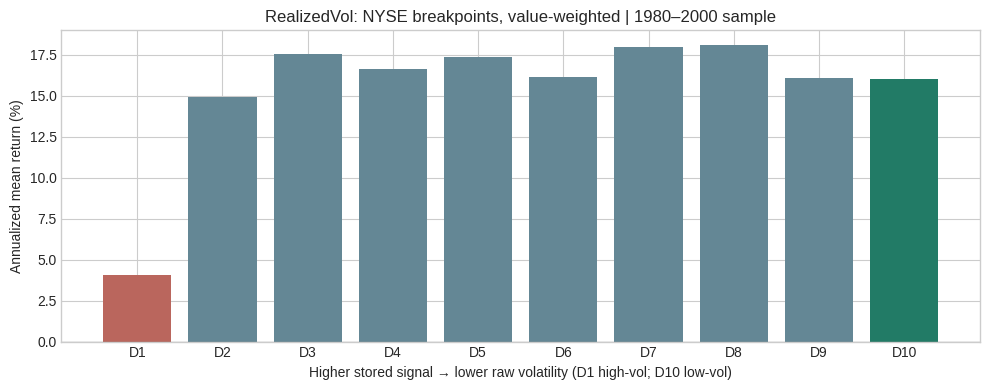

In [ ]:
# Use the same eligible sample and NYSE reference population for all ten deciles.
cutoffs = d.loc[d.exchcd == 1].groupby('date')['sig_l1'].quantile(np.arange(1, 10) / 10).unstack()
cutoffs.columns = [f'cut{k}' for k in range(1, 10)]
ranked = d.join(cutoffs, on='date')
ranked['decile'] = 1
for k in range(1, 10):
    ranked.loc[ranked.sig_l1 > ranked[f'cut{k}'], 'decile'] = k + 1
# Include equality at the top cutoff, exactly as in Q11.
ranked.loc[ranked.sig_l1 >= ranked.cut9, 'decile'] = 10

decile_ret = ranked.groupby(['date', 'decile']).apply(vw_return).unstack('decile')
assert decile_ret.notna().all().all()
np.testing.assert_allclose(decile_ret[1], low)
np.testing.assert_allclose(decile_ret[10], high)
decile_ann = decile_ret.astype(float).mean() * 12
print((decile_ann * 100).round(3).rename('Annual mean (%)').to_string())
print(f"Monotone increasing: {bool((decile_ann.diff().dropna() >= 0).all())}")
print(f"Adjacent increases: {int((decile_ann.diff().dropna() > 0).sum())} of 9")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, 11), decile_ann * 100, color=['#ba665d'] + ['#648795'] * 8 + ['#227b66'])
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(range(1, 11), [f'D{k}' for k in range(1, 11)])
ax.set_xlabel('Higher stored signal → lower raw volatility (D1 high-vol; D10 low-vol)')
ax.set_ylabel('Annualized mean return (%)')
ax.set_title('RealizedVol: NYSE breakpoints, value-weighted | 1980–2000 sample')
plt.tight_layout()
plt.show()


### Q14 — The memo

> **📝 Maximum eight sentences. This is the part I will actually read.**
>
> Your PM asks whether this signal is worth pursuing. Answer them.
>
> Cover: what you found; whether it replicated the published result and what you
> make of it if it didn't; whether the sort is monotone; which leg is doing the
> work; and one specific thing you would want to check before putting money on
> it.
>
> If your signal did not work, say so plainly. **Most signals do not work, and a
> project that establishes that honestly is a good project.** You will not be
> penalised for a negative result — only for pretending you didn't get one.

**Memo:**

RealizedVol is worth further research, but this backtest alone is not enough to invest.
Over 251 months from February 1980 to December 2000, low-volatility minus high-volatility stocks earns 11.96% per year with 24.96% volatility, a Sharpe ratio of 0.48, and a t-statistic of 2.19 before costs.
The direction matches the published result, but our t-statistic is weaker than the published 2.86, so this is not an exact replication.
Differences in sample period or portfolio construction could explain the gap, but this test does not establish which explanation is correct.
The ten-decile returns are not monotone: most middle groups earn roughly 15-18% annually, and D10 is not the best group.
D10 earns 16.04% annually, while D1 earns 4.07%.
The spread mainly reflects D1's weak return relative to the middle groups, rather than an unusually strong D10, and D1 is still positive rather than collapsing in absolute terms.
Before investing, I would test whether the spread survives realistic turnover-related trading costs and stock-borrow fees on the high-volatility short leg.
